# <center>Rozwiązywanie układów równań</center>

Instrukcja:
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi (w postaci kodu) z komentarzami w środowisku Jupyter Notebook i umieścić je na platformie e-learningowej.   

In [107]:
import main

import numpy as np
import scipy 
import matplotlib
import matplotlib.pyplot as plt
import timeit
from typing import Union, List, Tuple

**Cel zajęć:** Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania układów równań liniowych. To podstawowe zadanie algebry liniowej które macierzowo możemy zapisać jako:  
  
$
\mathbf{Ax}=\mathbf{b}
$ 
  
gdzie $\mathbf{A}$ - macierz współczynników, $\mathbf{x}$ - wektor zmiennych a $\mathbf{b}$ - wektor wyników prawej strony równania.  

Do oceny jakości rozwiązania będziemy wykorzystywać residuum (ang. *residual*)
$
\mathbf{r}=\mathbf{b}-\mathbf{Ax}
$ 
  

**Zadanie 1**   
 
1. Zaimplementuj funkcje *random\_matrix\_Ab* według opisu w pliku main.py generującą macierz kwadratową $\mathbf{A}$ i wektor $\mathbf{b}$ o zadanych wymiarach odpowiednio $m\times m$, $m\times 1$ i o wartościach losowych. W tym celu skorzystaj z funkcji *[randint](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.randint.html)*. W razie podania nieprawidłowej wartości m funkcja ma zwrócić wartość None.

2. Wygeneruj takie macierze dla $m=10,\ 20,\ 50,\ 100,\ 1000$. 

3. Zaimplementuj normę residual_norm zgodnie z opisem z main.py (używając *[norm](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.norm.html?highlight=norm#numpy.linalg.norm)*) 


In [108]:
def random_matrix_Ab(m:int):
    try:
        if not isinstance(m, int):
             return None
        A=np.random.randint(1,10,size=(m,m))
        b=np.random.randint(1,10, size=(m,1))
        return A,b
    except(ValueError,TypeError):
            return None
def residual_norm(A:np.ndarray,x:np.ndarray, b:np.ndarray):
    try:
        c=np.dot(A,x)
        r= b- c
        return np.linalg.norm(r)
    except(ValueError,TypeError):
            return None
    

In [109]:
random_matrix_Ab(10)
#random_matrix_Ab(20)
#random_matrix_Ab(50)
#random_matrix_Ab(100)
#random_matrix_Ab(1000)

(array([[9, 9, 2, 2, 3, 1, 3, 4, 8, 6],
        [8, 3, 3, 9, 1, 6, 2, 2, 9, 4],
        [1, 6, 2, 6, 8, 2, 3, 9, 9, 7],
        [8, 9, 2, 3, 9, 4, 2, 8, 7, 7],
        [7, 6, 4, 5, 3, 8, 5, 8, 7, 4],
        [1, 3, 6, 3, 8, 4, 8, 5, 3, 2],
        [5, 9, 2, 6, 1, 4, 2, 2, 6, 4],
        [2, 4, 2, 5, 1, 6, 4, 5, 9, 5],
        [7, 4, 2, 5, 1, 8, 8, 4, 3, 6],
        [2, 5, 6, 8, 1, 7, 5, 6, 7, 2]], dtype=int32),
 array([[6],
        [3],
        [4],
        [4],
        [5],
        [9],
        [1],
        [9],
        [6],
        [4]], dtype=int32))

Komentarz: stworzono funkcje random matrix, która tworzy macierz A i wektor b z losowych liczb. Zastosowano w tym celu np.random.randit, która od razu zwróci nam w typie np.array(tablica z biblioteki numphy). Dodatkowo stworzono funkcję wyliczającą normę residuum.

***Zadanie 2***   
 
1. Dla macierzy i wektorów wygenerowanych w poprzednim zadaniu znajdź rozwiązanie układu równań $\mathbf{Ax}=\mathbf{b}$ używając funkcji *[solve](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.solve.html?highlight=solve#numpy.linalg.solve)*. 

2. Sprawdź dokładność otrzymanego rozwiązania (oblicz normę residuum).

3. Określ uwarunkowanie macierzy $\mathbf{A}$ przy pomocy funkcji *[cond](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.cond.html?highlight=cond#numpy.linalg.cond)*. 

4. Odpowiedź na pytanie czy zakres wartości oraz wymiary macierzy mają wpływ na jakość otrzymanych wyników? 

5. Zbadać czas wykonania obliczeń przy pomocy funkcji *timeint*
  

In [110]:
A=np.array([[4, 6, 1, 2, 6, 4, 7, 7, 4, 5],
        [1, 6, 8, 9, 7, 7, 4, 6, 3, 5],
        [2, 1, 4, 3, 6, 9, 4, 2, 6, 5],
        [9, 5, 8, 8, 6, 3, 3, 9, 3, 7],
        [4, 2, 6, 8, 1, 4, 3, 9, 8, 5],
        [8, 4, 4, 9, 5, 1, 4, 6, 6, 6],
        [7, 9, 2, 5, 2, 6, 7, 5, 8, 5],
        [3, 6, 2, 8, 5, 8, 7, 9, 6, 2],
        [1, 2, 6, 2, 3, 2, 3, 9, 9, 5],
        [6, 3, 6, 6, 8, 8, 1, 1, 9, 9]])
b= np.array([[3],
        [6],
        [2],
        [3],
        [2],
        [6],
        [4],
        [8],
        [3],
        [4]])
x=np.linalg.solve(A,b)
print(x)
norma=residual_norm(A,x,b)
print(f"norma to: {norma:.2e}")
print(f"uwarunkowanei macierzy A to: {np.linalg.cond(A)}")


def przyklad():
        x=np.linalg.solve(A,b)
        norma=residual_norm(A,x,b)
print("Czas wykonywania obliczeń wybosi:")
print(timeit.timeit(przyklad, number=1000))

[[ 0.04202096]
 [ 0.41937226]
 [ 0.12718056]
 [ 0.39500136]
 [ 1.01436489]
 [-0.38020428]
 [-0.05236119]
 [-0.14688652]
 [ 0.7069327 ]
 [-1.31997395]]
norma to: 4.09e-15
uwarunkowanei macierzy A to: 46.3659640656267
Czas wykonywania obliczeń wybosi:
0.008441600002697669


Komentarz: wklejono stworzonej wczesniej A i b(tablice typu np.array) i rozwiazano Ax=b, poprzez funkcje np.linalg.solve. Dodatkowo wyliczono normę i sprawdzono czas takiej operacji poprzez timeit.

***Zadanie 3***  
Rozkład dowolnej macierzy metodą  *[dekompozycji na wartości singularne](https://pl.wikipedia.org/wiki/Rozk%C5%82ad_wed%C5%82ug_warto%C5%9Bci_osobliwych)* można w Pythonie przeprowadzić przy pomocy funkcji *[svd](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.svd.html)*. Rozkład dla przykładowej macierzy obrazuje kod: 

In [111]:
import numpy as np
import numpy.linalg as nplin

A = np.array([[1,2,3],[1,2,3],[1,2,3]])

# Użycie rozkładu SVD na macierzy A
U,S,V = nplin.svd(A)

print(S)
# Odtworzenie macierzy A przy pomocy metody SVD
A2 = np.dot(U * S, V)
 
print("Macierz A:\n {0}".format(A))
print("Macierz odtworzona z SVD:\n {0}".format(A2))

[6.4807407 0.        0.       ]
Macierz A:
 [[1 2 3]
 [1 2 3]
 [1 2 3]]
Macierz odtworzona z SVD:
 [[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]


Wykonaj następujące kroki:

1. Zdefiniuj funkcję inicjalizujące wektory *wartości singularnych* w następujący sposób:


- wektor nierosnących wartości singularnych w postaci wektora przestrzeni logarytmicznej, np:

In [112]:
S1 = np.logspace(100, 1, num=3)

- wektor nierosnących wartości singularnych, gdzie jedna wartość jest znacznie większa od pozostałych, np.:

In [113]:
S2 = np.logspace(100, 1, num=3)
S2[0] = S2[0]+100

- wektor nierosnących wartości, gdzie jedna wartość jest znacznie mniejsza od pozostałych. 

In [114]:
S3 = np.logspace(100, 1, num=3)
S3[-1] = S3[0]-100



W celu inicjalizacji takich wektorów zaimplementuje funkcje:  
    - *log\_sing\_value* zgodnie z opisem w main.py i użyciu funkcji *[logspace](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.logspace.html?highlight=logspace#numpy.logspace)* <br>
    - *order\_sing\_value* zgodnie z opisem w main.py


2. Zdefiniuj funkcję *create_matrix_from_A* z pliku main, która dla zadanej macierzy A z *zadania 1* i wektorów warości singularnych z punktu 1. tego zadania będzie zwracać odtworzoną macierz z podmienionym wektorem warości singularnych przy pomocy metody SVD, jak w przykładzie:
 

In [115]:
A = np.array([[1,2,3],[1,2,3],[1,2,3]])
U,S,V = nplin.svd(A)

A1 = np.dot(U * S1, V)
A2 = np.dot(U * S2, V)
A3 = np.dot(U * S3, V)
print('Macierz pierwotna:')
print(A)

print('Macierz na podstawie wartości S1:')
print(A1)

print('Macierz na podstawie wartości S2:')
print(A2)

print('Macierz na podstawie wartości S3:')
print(A3)

Macierz pierwotna:
[[1 2 3]
 [1 2 3]
 [1 2 3]]
Macierz na podstawie wartości S1:
[[1.5430335e+99 3.0860670e+99 4.6291005e+99]
 [1.5430335e+99 3.0860670e+99 4.6291005e+99]
 [1.5430335e+99 3.0860670e+99 4.6291005e+99]]
Macierz na podstawie wartości S2:
[[1.5430335e+99 3.0860670e+99 4.6291005e+99]
 [1.5430335e+99 3.0860670e+99 4.6291005e+99]
 [1.5430335e+99 3.0860670e+99 4.6291005e+99]]
Macierz na podstawie wartości S3:
[[-4.02045290e+99  3.94198798e+99  5.91298198e+99]
 [ 9.14289726e+99  1.91685719e+99  2.87528579e+99]
 [-4.93343857e+98  3.39935582e+99  5.09903374e+99]]




3. Dla otrzymanych macierzy oblicz wartości współczynnika uwarunkowania. 

4. Odpowiedz na pytanie: czy konieczne jest wyliczanie macierzy aby to zrobić?

5. Dla każdego $m$ sporządź wykres normy residuów rozwiązań i funkcji uwarunkowania macierzy. 




Czas to: 3.817 s
wartosc współczynnika uwarunkowania: 10000.000000000182
Norma: 4.162064252821826e-12


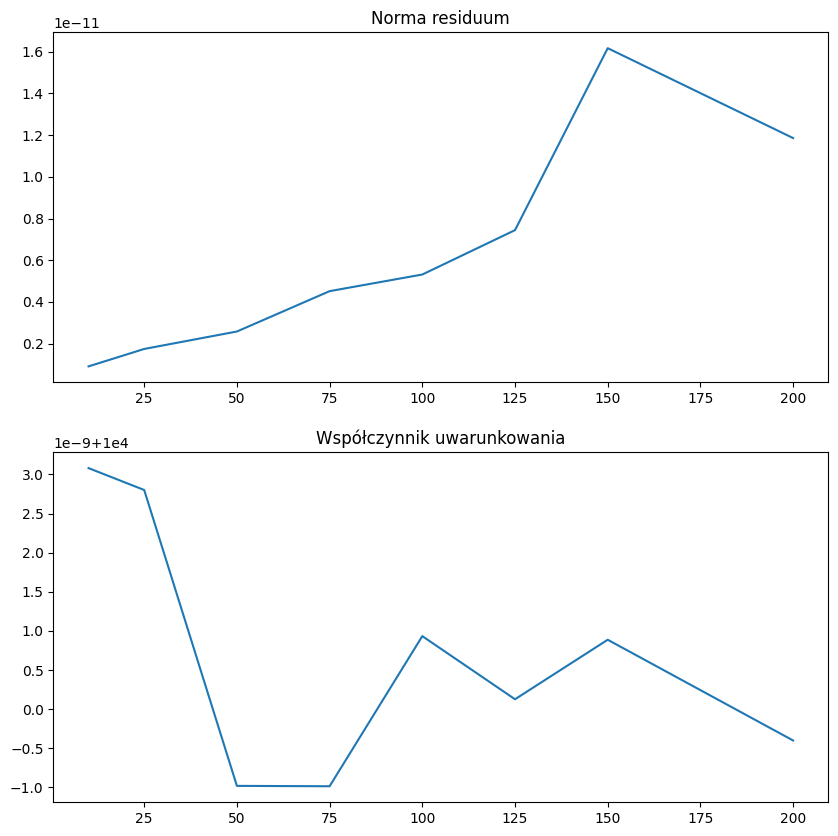

In [129]:
def log_sing_value(n:int, min_order:Union[int,float], max_order:Union[int,float]):

    try:
        if n<=0 or not isinstance(n,int) or not isinstance(max_order,(int,float)) or not isinstance(min_order,(int,float)):
             return None
        wartosci = np.logspace(start=max_order, stop=min_order, num=n, base=10.0)
        return wartosci
    except(ValueError,TypeError):
        return None

    
def order_sing_value(n:int, order:Union[int,float] = 2, site:str = 'gre'):
    try:
        n = int(n)
        order = float(order)

        zmiana = 10**order
        wartosci = np.random.rand(n)*10
        wartosci = np.sort(wartosci)[::-1] #odwraca kolejność
        if site == 'low':
            wartosci[-1] = wartosci[-1] *zmiana
        elif site == 'gre':
            wartosci[0] = wartosci[0] * zmiana
        else:
            return None
        wartosci = np.sort(wartosci)[::-1] #ponowne sortowanie
        return wartosci

    except(ValueError,TypeError):
        return None


def create_matrix_from_A(A:np.ndarray, sing_value:np.ndarray):
    try:
        U, s, V = np.linalg.svd(A)
        if s.shape != sing_value.shape:
            return None
        A1 = np.dot(U * sing_value, V)
        return A1

    except(ValueError,TypeError, AttributeError):
        return None

m = 87
A=np.random.randint(1,10,size=(m,m))
b=np.random.randint(1,10, size=(m))

sing_value_nowy = log_sing_value(n=m, min_order=-4, max_order=0) 

def przyklad2():
    A_nowa = create_matrix_from_A(A, sing_value_nowy) 
    
    if A_nowa is None:
         return None, None
    
    wsp_uwarunkowania = np.linalg.cond(A_nowa)
    x2 = np.linalg.solve(A_nowa, b)

    norma = residual_norm(A_nowa, x2, b) 
    return wsp_uwarunkowania, norma

czas = timeit.timeit(przyklad2, number=1000) 
print(f"Czas to: {czas:.3f} s")
wsp, norm = przyklad2()

print(f"wartosc współczynnika uwarunkowania: {wsp}")
print(f"Norma: {norm}")

m_values = [10, 25, 50, 75, 100, 125, 150, 200]
norm_results = []
cond_results = []

for m in m_values:
    sing_value_nowy = log_sing_value(n=m, min_order=-4, max_order=0)
    A=np.random.randint(1,10,size=(m,m))
    b=np.random.randint(1,10, size=(m))
    A_nowa = create_matrix_from_A(A, sing_value_nowy)

    wsp_uwarunkowania = np.linalg.cond(A_nowa)
    x2 = np.linalg.solve(A_nowa, b)
    norma = residual_norm(A_nowa, x2, b) 

    norm_results.append(norma)
    cond_results.append(wsp_uwarunkowania)
if norm_results:
    plt.figure(figsize=(10, 10))
    
    plt.subplot(2, 1, 1) 
    plt.plot(m_values[:len(norm_results)], norm_results)
    plt.title('Norma residuum')

    plt.subplot(2, 1, 2) 
    plt.plot(m_values[:len(cond_results)], cond_results)
    plt.title("Współczynnik uwarunkowania")

    plt.show()

Komentarz: Zaimplementowano wszystko według instrukcji. Dodano wiele warunków, które sprwadzają, czy ciągle mamy dobrą macierz i dobre dane. Żeby stworzyć wykresy wiele rzeczy trzebabyło stworzyć od nowa, ponieważ miało się ich stworzyć kilka, a nie jedna(w pętli). Oba wykresy stworzono poprzez funkję plt.plot + subplot, który pomógł uporządkować dwa wykresy jeden pod drugim. Zmierzyłem również dodatkowo czas tej operacji, pomimo, że nie ma tego w poleceniu.

Materiały uzupełniające:
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)